# Global Superstore — Complete Data Analytics Case Study

**Tools:** Python + Pandas + NumPy + Matplotlib

This notebook is designed to run from top to bottom without manual code changes when
`superstore.csv` is available in the same folder as the notebook or at `/mnt/data/superstore.csv`.

### Topics covered
1. Data loading
2. Data validation and quality checks
3. Data cleaning
4. Feature engineering
5. Executive KPIs
6. Category and sub-category analysis
7. Customer analysis
8. Product analysis
9. Segment analysis
10. Market and regional analysis
11. Country and state analysis
12. Shipping analysis
13. Discount analysis
14. Time-series analysis
15. Correlation analysis
16. Outlier analysis
17. Business questions
18. Business insights
19. Export of analytical datasets for Excel / Power BI


In [1]:
# 0. Import libraries
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [2]:
# 1. Locate and load the dataset
possible_paths = [
    Path("superstore.csv"),
    Path("/mnt/data/superstore.csv"),
    Path("data/superstore.csv"),
]

DATA_PATH = next((path for path in possible_paths if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "superstore.csv was not found. Put the CSV beside this notebook "
        "or update DATA_PATH in this cell."
    )

df = pd.read_csv(DATA_PATH)

print(f"Dataset: {DATA_PATH}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

display(df.head())


Dataset: superstore.csv
Rows: 51,290
Columns: 27


,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,Order.Priority,Product.ID,Product.Name,Profit,Quantity,Region,Row.ID,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.00,US,1,2011-01-07 00:00:00.000,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.33,3,West,36624,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.00,US,1,2011-01-21 00:00:00.000,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.29,2,West,37033,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.00,US,1,2011-08-05 00:00:00.000,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",9.84,3,West,31468,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.00,US,1,2011-08-05 00:00:00.000,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.26,2,West,31469,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.00,US,1,2011-09-29 00:00:00.000,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.11,1,West,32440,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


## 2. Dataset Structure

In [3]:
# Basic structure
print("Shape:", df.shape)
print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))


Shape: (51290, 27)

Column names:
01. Category
02. City
03. Country
04. Customer.ID
05. Customer.Name
06. Discount
07. Market
08. 记录数
09. Order.Date
10. Order.ID
11. Order.Priority
12. Product.ID
13. Product.Name
14. Profit
15. Quantity
16. Region
17. Row.ID
18. Sales
19. Segment
20. Ship.Date
21. Ship.Mode
22. Shipping.Cost
23. State
24. Sub.Category
25. Year
26. Market2
27. weeknum

Data types:


,Data Type
Category,object
City,object
Country,object
Customer.ID,object
Customer.Name,object
Discount,float64
Market,object
记录数,int64
Order.Date,object
Order.ID,object


In [4]:
# Numeric summary
display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Category,51290,3,Office Supplies,31273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,51290,3636,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,51290,147,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer.ID,51290,4873,JG-158051,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer.Name,51290,795,Muhammed Yedwab,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Discount,"51,290.00",NaN,NaN,NaN,0.14,0.21,0.00,0.00,0.00,0.20,0.85
Market,51290,7,APAC,11002,NaN,NaN,NaN,NaN,NaN,NaN,NaN
记录数,"51,290.00",NaN,NaN,NaN,1.00,0.00,1.00,1.00,1.00,1.00,1.00
Order.Date,51290,1430,2014-06-18 00:00:00.000,135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order.ID,51290,25035,CA-2014-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Quality Checks

In [5]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing_table = pd.DataFrame({
    "Column": missing.index,
    "Missing_Values": missing.values,
    "Missing_Percent": (missing.values / len(df) * 100)
})

display(missing_table)


,Column,Missing_Values,Missing_Percent
0,Category,0,0.00
1,City,0,0.00
2,Country,0,0.00
3,Customer.ID,0,0.00
4,Customer.Name,0,0.00
5,Discount,0,0.00
6,Market,0,0.00
7,记录数,0,0.00
8,Order.Date,0,0.00
9,Order.ID,0,0.00


In [6]:
# Duplicate checks
duplicate_rows = int(df.duplicated().sum())

if "Row.ID" in df.columns:
    duplicate_row_ids = int(df["Row.ID"].duplicated().sum())
else:
    duplicate_row_ids = None

print("Duplicate complete rows:", duplicate_rows)
print("Duplicate Row.ID values:", duplicate_row_ids)


Duplicate complete rows: 0
Duplicate Row.ID values: 0


In [7]:
# Validate important numeric columns
numeric_columns = [
    "Sales", "Profit", "Quantity", "Discount", "Shipping.Cost"
]

numeric_columns = [c for c in numeric_columns if c in df.columns]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

display(df[numeric_columns].isna().sum().to_frame("Invalid_or_Missing"))


,Invalid_or_Missing
Sales,0
Profit,0
Quantity,0
Discount,0
Shipping.Cost,0


## 4. Data Cleaning and Feature Engineering

In [8]:
# Convert date columns safely
for column in ["Order.Date", "Ship.Date"]:
    if column in df.columns:
        df[column] = pd.to_datetime(df[column], errors="coerce")

# Remove exact duplicate rows
df = df.drop_duplicates().copy()

# Create analytical fields
df["Shipping_Days"] = (df["Ship.Date"] - df["Order.Date"]).dt.days

df["Profit_Margin"] = np.where(
    df["Sales"].ne(0),
    df["Profit"] / df["Sales"],
    np.nan
)

df["Profit_Status"] = np.select(
    [
        df["Profit"].gt(0),
        df["Profit"].lt(0)
    ],
    [
        "Profitable",
        "Loss"
    ],
    default="Break Even"
)

df["Order_Year"] = df["Order.Date"].dt.year
df["Order_Month"] = df["Order.Date"].dt.month
df["Order_Month_Name"] = df["Order.Date"].dt.strftime("%b")
df["Order_Quarter"] = df["Order.Date"].dt.to_period("Q").astype(str)

df["Discount_Band"] = pd.cut(
    df["Discount"],
    bins=[-np.inf, 0, 0.10, 0.20, 0.30, np.inf],
    labels=["No Discount", "1-10%", "11-20%", "21-30%", "31%+"],
    right=True
)

print("Cleaning and feature engineering completed.")
display(df.head())


Cleaning and feature engineering completed.


,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,Order.Priority,Product.ID,Product.Name,Profit,Quantity,Region,Row.ID,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum,Shipping_Days,Profit_Margin,Profit_Status,Order_Year,Order_Month,Order_Month_Name,Order_Quarter,Discount_Band
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.00,US,1,2011-01-07,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.33,3,West,36624,19,Consumer,2011-01-09,Second Class,4.37,California,Paper,2011,North America,2,2,0.49,Profitable,2011,1,Jan,2011Q1,No Discount
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.00,US,1,2011-01-21,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.29,2,West,37033,19,Consumer,2011-01-26,Standard Class,0.94,California,Paper,2011,North America,4,5,0.49,Profitable,2011,1,Jan,2011Q1,No Discount
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.00,US,1,2011-08-05,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",9.84,3,West,31468,21,Consumer,2011-08-09,Standard Class,1.81,California,Paper,2011,North America,32,4,0.47,Profitable,2011,8,Aug,2011Q3,No Discount
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.00,US,1,2011-08-05,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.26,2,West,31469,111,Consumer,2011-08-09,Standard Class,4.59,California,Paper,2011,North America,32,4,0.48,Profitable,2011,8,Aug,2011Q3,No Discount
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.00,US,1,2011-09-29,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.11,1,West,32440,6,Consumer,2011-10-03,Standard Class,1.32,California,Paper,2011,North America,40,4,0.52,Profitable,2011,9,Sep,2011Q3,No Discount


In [9]:
# Final validation after cleaning
print("Rows after cleaning:", f"{len(df):,}")
print("Columns:", f"{len(df.columns):,}")
print("Missing Order.Date:", int(df["Order.Date"].isna().sum()))
print("Missing Ship.Date:", int(df["Ship.Date"].isna().sum()))
print("Missing Sales:", int(df["Sales"].isna().sum()))
print("Missing Profit:", int(df["Profit"].isna().sum()))


Rows after cleaning: 51,290
Columns: 35
Missing Order.Date: 0
Missing Ship.Date: 0
Missing Sales: 0
Missing Profit: 0


## 5. Executive KPI Analysis

In [10]:
# Executive KPIs
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = total_profit / total_sales if total_sales != 0 else np.nan
total_orders = df["Order.ID"].nunique()
total_customers = df["Customer.ID"].nunique()
total_quantity = df["Quantity"].sum()
average_order_value = total_sales / total_orders if total_orders else np.nan
average_shipping_days = df["Shipping_Days"].mean()

kpis = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Profit",
        "Profit Margin",
        "Total Orders",
        "Total Customers",
        "Total Quantity",
        "Average Order Value",
        "Average Shipping Days"
    ],
    "Value": [
        total_sales,
        total_profit,
        profit_margin,
        total_orders,
        total_customers,
        total_quantity,
        average_order_value,
        average_shipping_days
    ]
})

display(kpis)


,KPI,Value
0,Total Sales,"12,642,905.00"
1,Total Profit,"1,467,457.29"
2,Profit Margin,0.12
3,Total Orders,"25,035.00"
4,Total Customers,"4,873.00"
5,Total Quantity,"178,312.00"
6,Average Order Value,505.01
7,Average Shipping Days,3.97


## 6. Category and Sub-Category Analysis

In [11]:
def summarize(group_columns):
    result = (
        df.groupby(group_columns, dropna=False)
        .agg(
            Sales=("Sales", "sum"),
            Profit=("Profit", "sum"),
            Quantity=("Quantity", "sum"),
            Orders=("Order.ID", "nunique"),
            Customers=("Customer.ID", "nunique")
        )
        .reset_index()
    )
    result["Profit_Margin"] = np.where(
        result["Sales"].ne(0),
        result["Profit"] / result["Sales"],
        np.nan
    )
    return result

category = summarize(["Category"]).sort_values("Sales", ascending=False)
subcategory = summarize(["Sub.Category"]).sort_values("Profit", ascending=False)

display(category)
display(subcategory)


,Category,Sales,Profit,Quantity,Orders,Customers,Profit_Margin
2,Technology,4744691,"663,778.73",35176,8354,3863,0.14
0,Furniture,4110884,"285,204.72",34954,8195,3691,0.07
1,Office Supplies,3787330,"518,473.83",108182,19003,4771,0.14


,Sub.Category,Sales,Profit,Quantity,Orders,Customers,Profit_Margin
6,Copiers,1509439,"258,567.55",7454,2120,1616,0.17
13,Phones,1706874,"216,717.01",11870,3133,2211,0.13
4,Bookcases,1466559,"161,924.42",8310,2284,1742,0.11
1,Appliances,1011081,"141,680.59",6078,1686,1413,0.14
5,Chairs,1501682,"140,396.27",12336,3187,2171,0.09
0,Accessories,749307,"129,626.31",10946,2889,2082,0.17
14,Storage,1127124,"108,461.49",16917,4534,2939,0.10
3,Binders,461952,"72,449.85",21429,5392,3143,0.16
12,Paper,244307,"59,207.68",12822,3234,2144,0.24
11,Machines,779071,"58,867.87",4906,1422,1199,0.08


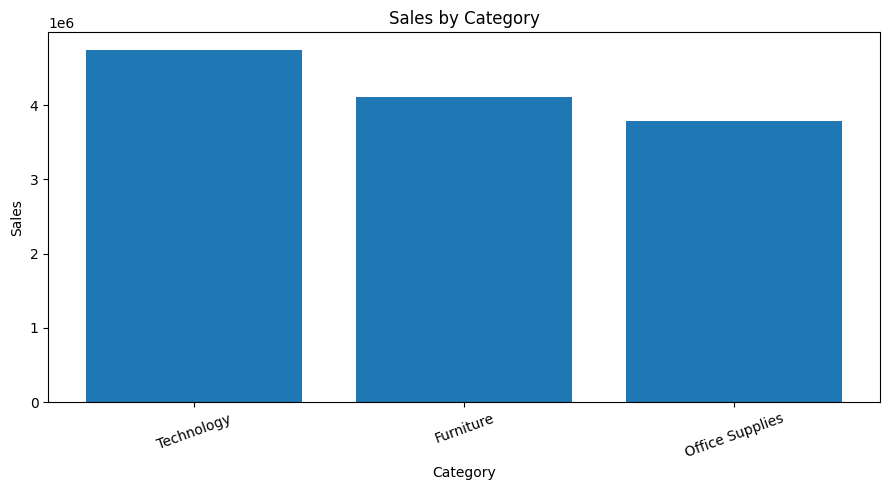

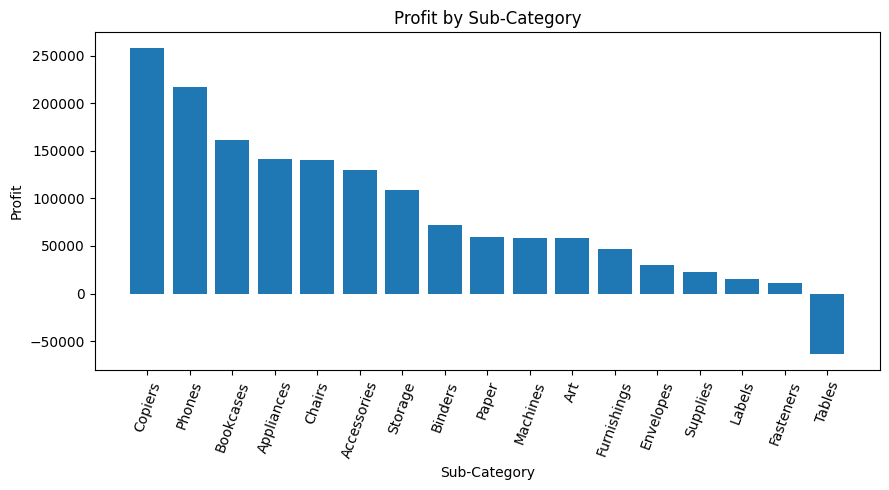

In [12]:
# Category visualizations
fig = plt.figure(figsize=(9, 5))
plt.bar(category["Category"].astype(str), category["Sales"])
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(9, 5))
plt.bar(subcategory["Sub.Category"].astype(str), subcategory["Profit"])
plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()


## 7. Customer Analysis

In [13]:
customer = (
    df.groupby(["Customer.ID", "Customer.Name", "Segment"], dropna=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order.ID", "nunique"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

customer["Profit_Margin"] = np.where(
    customer["Sales"].ne(0),
    customer["Profit"] / customer["Sales"],
    np.nan
)

top_customers_sales = customer.sort_values("Sales", ascending=False).head(20)
top_customers_profit = customer.sort_values("Profit", ascending=False).head(20)
loss_customers = customer[customer["Profit"] < 0].sort_values("Profit").head(20)

print("Top customers by sales")
display(top_customers_sales)

print("Top customers by profit")
display(top_customers_profit)

print("Loss-making customers")
display(loss_customers)


Top customers by sales


,Customer.ID,Customer.Name,Segment,Sales,Profit,Orders,Quantity,Profit_Margin
4306,SM-203204,Sean Miller,Home Office,25042,"-1,980.74",5,50,-0.08
4564,TC-209804,Tamara Chand,Corporate,19050,"8,981.32",5,42,0.47
1042,CS-118451,Cari Sayre,Corporate,16655,"2,995.58",11,101,0.18
4359,SP-209202,Susan Pistek,Consumer,16566,"4,974.51",12,107,0.30
4792,VG-218051,Vivek Grady,Corporate,15654,"2,748.19",7,67,0.18
3816,RB-193604,Raymond Buch,Consumer,15117,"6,976.10",6,71,0.46
3611,PF-191201,Peter Fuller,Consumer,15063,968.27,8,80,0.06
4487,TA-213854,Tom Ashbrook,Home Office,14596,"4,703.79",4,36,0.32
490,BF-110051,Barry Franz,Home Office,14563,"2,272.49",9,88,0.16
37,AB-101054,Adrian Barton,Consumer,14476,"5,444.81",10,73,0.38


Top customers by profit


,Customer.ID,Customer.Name,Segment,Sales,Profit,Orders,Quantity,Profit_Margin
4564,TC-209804,Tamara Chand,Corporate,19050,"8,981.32",5,42,0.47
3816,RB-193604,Raymond Buch,Consumer,15117,"6,976.10",6,71,0.46
4137,SC-200954,Sanjit Chand,Consumer,14145,"5,757.41",9,87,0.41
2015,HL-150404,Hunter Lopez,Consumer,12875,"5,622.43",6,50,0.44
37,AB-101054,Adrian Barton,Consumer,14476,"5,444.81",10,73,0.38
4359,SP-209202,Susan Pistek,Consumer,16566,"4,974.51",12,107,0.30
4487,TA-213854,Tom Ashbrook,Home Office,14596,"4,703.79",4,36,0.32
749,CA-127751,Cynthia Arntzen,Consumer,11493,"4,045.88",5,42,0.35
3649,PJ-188352,Patrick Jones,Corporate,8509,"3,986.00",3,26,0.47
969,CM-123854,Christopher Martinez,Consumer,8953,"3,899.89",4,34,0.44


Loss-making customers


,Customer.ID,Customer.Name,Segment,Sales,Profit,Orders,Quantity,Profit_Margin
1085,CS-125054,Cindy Stewart,Consumer,5691,"-6,626.39",6,40,-1.16
1380,DM-33452,Denise Monton,Corporate,4664,"-5,377.68",3,29,-1.15
1908,GT-146354,Grant Thornton,Corporate,9351,"-4,108.66",3,26,-0.44
4388,SS-201402,Saphhira Shifley,Corporate,5653,"-3,957.14",5,41,-0.70
2823,LF-171854,Luke Foster,Consumer,3931,"-3,583.98",7,69,-0.91
4370,SR-204254,Sharelle Roach,Home Office,3234,"-3,333.91",5,34,-1.03
1981,HG-149654,Henry Goldwyn,Corporate,3250,"-2,797.96",12,68,-0.86
4320,SN-205601,Skye Norling,Home Office,6795,"-2,597.13",6,47,-0.38
3337,MT-80702,Michelle Tran,Home Office,2025,"-2,519.63",4,31,-1.24
2138,JC-61052,Julie Creighton,Corporate,3855,"-2,470.73",5,42,-0.64


## 8. Product Analysis

In [14]:
product = (
    df.groupby(["Product.ID", "Product.Name"], dropna=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Order.ID", "nunique")
    )
    .reset_index()
)

product["Profit_Margin"] = np.where(
    product["Sales"].ne(0),
    product["Profit"] / product["Sales"],
    np.nan
)

top_products = product.sort_values("Sales", ascending=False).head(20)
top_profit_products = product.sort_values("Profit", ascending=False).head(20)
loss_products = product.sort_values("Profit").head(20)

print("Top products by sales")
display(top_products)

print("Top products by profit")
display(top_profit_products)

print("Loss-making products")
display(loss_products)


Top products by sales


,Product.ID,Product.Name,Sales,Profit,Quantity,Orders,Profit_Margin
9388,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61600,"25,199.93",20,5,0.41
10632,TEC-PH-10004664,"Nokia Smart Phone, with Caller ID",30042,"5,455.95",52,10,0.18
4017,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,27454,"7,753.04",31,10,0.28
9721,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638,"-1,811.08",6,1,-0.08
10646,TEC-PH-10004823,"Nokia Smart Phone, Full Size",22261,"8,121.48",39,11,0.36
745,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,21870,0.00,39,8,0.00
541,FUR-CH-10000027,"SAFCO Executive Leather Armchair, Black",21329,"1,363.23",50,12,0.06
2882,OFF-AP-10004512,"Hoover Stove, Red",21148,"10,345.58",38,7,0.49
3744,OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,19824,"2,233.51",37,11,0.11
3634,OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,19026,760.98,48,9,0.04


Top products by profit


,Product.ID,Product.Name,Sales,Profit,Quantity,Orders,Profit_Margin
9388,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61600,"25,199.93",20,5,0.41
2882,OFF-AP-10004512,"Hoover Stove, Red",21148,"10,345.58",38,7,0.49
10646,TEC-PH-10004823,"Nokia Smart Phone, Full Size",22261,"8,121.48",39,11,0.36
4017,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,27454,"7,753.04",31,10,0.28
9099,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18840,"6,983.88",38,8,0.37
776,FUR-CH-10002250,"Office Star Executive Leather Armchair, Black",15289,"6,123.26",37,10,0.40
10632,TEC-PH-10004664,"Nokia Smart Phone, with Caller ID",30042,"5,455.95",52,10,0.18
2681,OFF-AP-10002330,"Hamilton Beach Stove, Silver",18248,"5,452.46",38,7,0.30
10097,TEC-PH-10000303,"Samsung Smart Phone, VoIP",16797,"5,356.81",31,6,0.32
766,FUR-CH-10002203,"SAFCO Executive Leather Armchair, Black",12301,"5,003.10",30,5,0.41


Loss-making products


,Product.ID,Product.Name,Sales,Profit,Quantity,Orders,Profit_Margin
9574,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,11100,"-8,879.97",9,3,-0.80
2614,OFF-AP-10001623,"Hoover Stove, White",11730,"-4,958.16",31,6,-0.42
9605,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16830,"-4,589.97",18,4,-0.27
10424,TEC-PH-10002991,"Apple Smart Phone, Full Size",7258,"-4,574.64",20,4,-0.63
9984,TEC-MOT-10003050,"Motorola Smart Phone, Cordless",10350,"-3,998.68",24,7,-0.39
9876,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,8000,"-3,839.99",4,1,-0.48
699,FUR-CH-10001582,"Office Star Executive Leather Armchair, Black",6498,"-3,066.78",22,5,-0.47
1993,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9918,"-2,876.12",27,5,-0.29
2157,FUR-TA-10002885,"Lesro Computer Table, Fully Assembled",1200,"-2,798.49",14,3,-2.33
2118,FUR-TA-10002172,"Hon Conference Table, Rectangular",3667,"-2,619.31",12,3,-0.71


## 9. Segment, Market and Region Analysis

In [15]:
segment = summarize(["Segment"]).sort_values("Profit", ascending=False)
market = summarize(["Market"]).sort_values("Sales", ascending=False)
region = summarize(["Region"]).sort_values("Profit", ascending=False)

display(segment)
display(market)
display(region)


,Segment,Sales,Profit,Quantity,Orders,Customers,Profit_Margin
0,Consumer,6508141,"749,239.78",92157,13104,2509,0.12
1,Corporate,3824808,"441,208.33",53565,7673,1457,0.12
2,Home Office,2309956,"277,009.18",32590,4687,907,0.12


,Market,Sales,Profit,Quantity,Orders,Customers,Profit_Margin
0,APAC,3585833,"436,000.05",41226,5437,796,0.12
4,EU,2938139,"372,829.74",37773,4593,795,0.13
6,US,2297354,"286,397.02",37873,5009,793,0.12
5,LATAM,2164687,"221,643.49",38526,5138,794,0.10
3,EMEA,806184,"43,897.97",11517,2462,760,0.05
1,Africa,783776,"88,871.63",10564,2232,754,0.11
2,Canada,66932,"17,817.39",833,201,181,0.27


,Region,Sales,Profit,Quantity,Orders,Customers,Profit_Margin
3,Central,2822399,"311,403.98",41762,5249,2077,0.11
7,North,1248192,"194,597.95",18021,2356,1283,0.16
8,North Asia,848349,"165,578.42",8851,1150,617,0.20
10,South,1600960,"140,355.77",25206,3270,1745,0.09
4,Central Asia,752839,"132,480.19",7715,1026,570,0.18
9,Oceania,1100207,"120,089.11",12838,1744,705,0.11
12,West,725514,"108,418.45",12266,1611,686,0.15
6,East,678834,"91,522.78",10618,1401,674,0.13
0,Africa,783776,"88,871.63",10564,2232,754,0.11
5,EMEA,806184,"43,897.97",11517,2462,760,0.05


## 10. Country and State Analysis

In [16]:
country = summarize(["Country"]).sort_values("Sales", ascending=False)
state = summarize(["State"]).sort_values("Profit", ascending=False)

print("Top 30 countries by sales")
display(country.head(30))

print("Top 30 states by profit")
display(state.head(30))

print("Bottom 30 states by profit")
display(state.sort_values("Profit").head(30))


Top 30 countries by sales


,Country,Sales,Profit,Quantity,Orders,Customers,Profit_Margin
139,United States,2297354,"286,397.02",37873,5009,793,0.12
6,Australia,925257,"103,907.43",10673,1420,660,0.11
44,France,858930,"109,029.00",10804,1222,679,0.13
26,China,700591,"150,683.08",7081,925,549,0.22
47,Germany,628857,"107,322.82",7745,907,582,0.17
81,Mexico,622620,"102,818.10",10011,1329,670,0.17
57,India,589664,"129,071.84",5758,785,494,0.22
138,United Kingdom,528570,"111,900.15",6161,775,529,0.21
58,Indonesia,404887,"15,608.68",5237,698,469,0.04
17,Brazil,361098,"30,090.50",6148,784,472,0.08


Top 30 states by profit


,State,Sales,Profit,Quantity,Orders,Customers,Profit_Margin
311,England,485166,"99,907.73",5656,699,505,0.21
192,California,457731,"76,381.39",7667,1021,577,0.17
703,New York,310914,"74,038.55",4224,562,415,0.24
435,Ile-de-France,317818,"44,055.92",3839,468,383,0.14
702,New South Wales,270509,"43,695.98",2921,388,321,0.16
722,North Rhine-Westphalia,216458,"42,347.87",2660,336,293,0.20
867,San Salvador,153648,"35,883.38",2273,307,257,0.23
1050,Washington,138656,"33,402.65",1883,256,224,0.24
646,Michigan,76281,"24,463.19",946,117,106,0.32
955,São Paulo,98418,"21,878.02",1530,207,178,0.22


Bottom 30 states by profit


,State,Sales,Profit,Quantity,Orders,Customers,Profit_Margin
449,Istanbul,31041,"-29,033.70",930,202,178,-0.94
548,Lagos,17188,"-25,922.51",733,150,138,-1.51
982,Texas,170187,"-25,729.36",3724,487,370,-0.15
742,Ohio,78253,"-16,971.38",1759,236,202,-0.22
452,Izmir,15165,"-15,729.80",307,59,59,-1.04
777,Pennsylvania,116522,"-15,559.96",2153,288,257,-0.13
334,Francisco Morazán,48061,"-15,007.42",1334,178,160,-0.31
767,Panama,41504,"-14,978.50",1198,172,159,-0.36
809,Punjab,60075,"-14,665.05",838,109,101,-0.24
939,Stockholm,21587,"-13,806.44",561,74,72,-0.64


## 11. Shipping Analysis

In [17]:
shipping = (
    df.groupby("Ship.Mode", dropna=False)
    .agg(
        Orders=("Order.ID", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Average_Shipping_Days=("Shipping_Days", "mean")
    )
    .reset_index()
)

shipping["Profit_Margin"] = np.where(
    shipping["Sales"].ne(0),
    shipping["Profit"] / shipping["Sales"],
    np.nan
)

display(shipping.sort_values("Profit", ascending=False))


,Ship.Mode,Orders,Sales,Profit,Quantity,Average_Shipping_Days,Profit_Margin
3,Standard Class,15154,7578889,"890,596.02",107319,5.00,0.12
2,Second Class,5119,2565747,"292,583.53",35724,3.23,0.11
0,First Class,3821,1831067,"208,104.68",26039,2.18,0.11
1,Same Day,1347,667202,"76,173.07",9230,0.04,0.11


## 12. Discount Analysis

In [18]:
discount = (
    df.groupby("Discount", dropna=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("Row.ID", "count")
    )
    .reset_index()
    .sort_values("Discount")
)

discount["Profit_Margin"] = np.where(
    discount["Sales"].ne(0),
    discount["Profit"] / discount["Sales"],
    np.nan
)

display(discount)


,Discount,Sales,Profit,Quantity,Transactions,Profit_Margin
0,0.00,6992734,"1,770,695.27",98768,29009,0.25
1,0.00,261395,"57,976.58",1657,461,0.22
2,0.07,121620,"21,148.50",533,150,0.17
3,0.10,1579618,"259,064.18",15417,4068,0.16
4,0.15,306037,"27,375.90",2021,541,0.09
5,0.17,247404,"28,163.07",2720,735,0.11
6,0.20,1203855,"117,715.87",18653,4998,0.10
7,0.20,16213,-595.27,135,41,-0.04
8,0.25,88063,800.59,826,198,0.01
9,0.27,89351,"-1,675.08",1453,388,-0.02


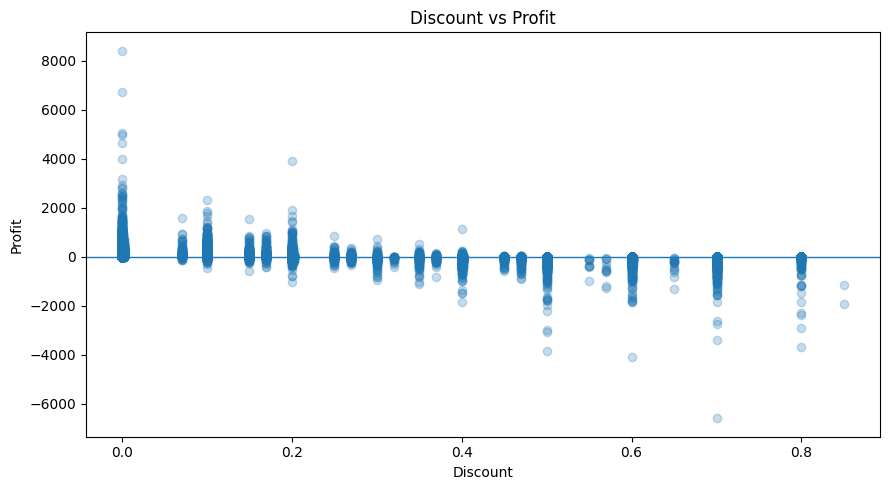

In [19]:
fig = plt.figure(figsize=(9, 5))
plt.scatter(df["Discount"], df["Profit"], alpha=0.25)
plt.axhline(0, linewidth=1)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


## 13. Time-Series Analysis

In [20]:
monthly = (
    df.dropna(subset=["Order.Date"])
    .groupby(["Order_Year", "Order_Month"])
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order.ID", "nunique")
    )
    .reset_index()
    .sort_values(["Order_Year", "Order_Month"])
)

monthly["Period"] = pd.to_datetime(
    monthly["Order_Year"].astype(int).astype(str)
    + "-"
    + monthly["Order_Month"].astype(int).astype(str)
    + "-01"
)

monthly["Profit_Margin"] = np.where(
    monthly["Sales"].ne(0),
    monthly["Profit"] / monthly["Sales"],
    np.nan
)

display(monthly)


,Order_Year,Order_Month,Sales,Profit,Orders,Period,Profit_Margin
0,2011,1,98902,"8,321.80",216,2011-01-01,0.08
1,2011,2,91152,"12,417.91",183,2011-02-01,0.14
2,2011,3,145726,"15,303.57",277,2011-03-01,0.11
3,2011,4,116927,"12,902.32",267,2011-04-01,0.11
4,2011,5,146762,"12,183.83",295,2011-05-01,0.08
5,2011,6,215214,"23,415.25",468,2011-06-01,0.11
6,2011,7,115518,"5,585.00",250,2011-07-01,0.05
7,2011,8,207570,"23,713.67",443,2011-08-01,0.11
8,2011,9,290230,"35,776.88",527,2011-09-01,0.12
9,2011,10,199070,"25,963.42",401,2011-10-01,0.13


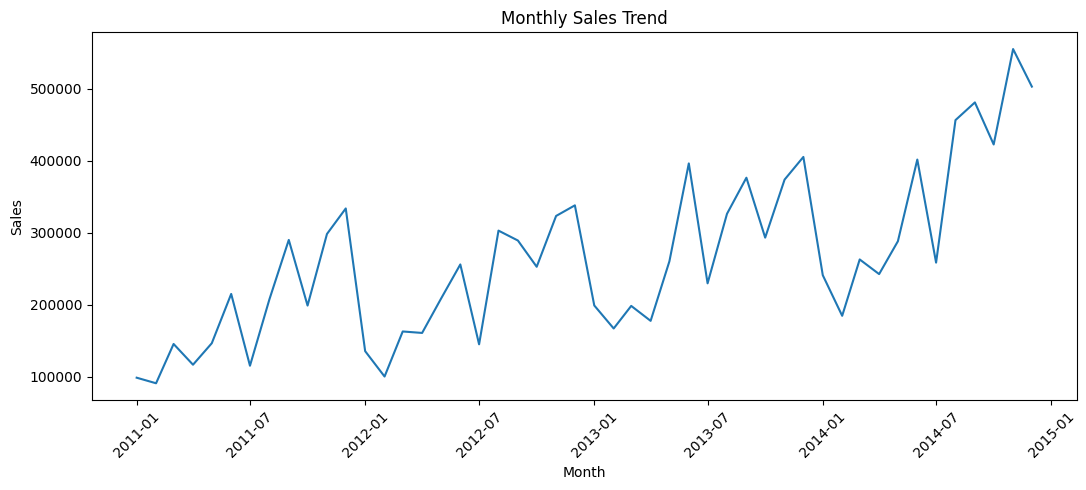

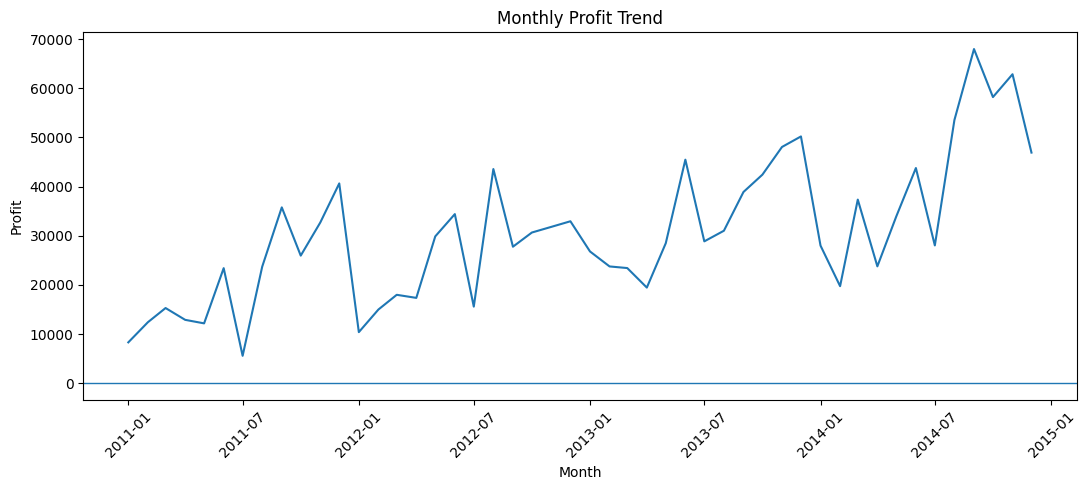

In [21]:
fig = plt.figure(figsize=(11, 5))
plt.plot(monthly["Period"], monthly["Sales"])
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(11, 5))
plt.plot(monthly["Period"], monthly["Profit"])
plt.axhline(0, linewidth=1)
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 14. Yearly Analysis

In [22]:
yearly = (
    df.groupby("Order_Year", dropna=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order.ID", "nunique"),
        Customers=("Customer.ID", "nunique")
    )
    .reset_index()
)

yearly["Profit_Margin"] = np.where(
    yearly["Sales"].ne(0),
    yearly["Profit"] / yearly["Sales"],
    np.nan
)

display(yearly)


,Order_Year,Sales,Profit,Orders,Customers,Profit_Margin
0,2011,2259511,"248,940.81",4440,2890,0.11
1,2012,2677493,"307,415.28",5343,3121,0.11
2,2013,3405860,"406,935.23",6721,3591,0.12
3,2014,4300041,"504,165.97",8531,3948,0.12


## 15. Correlation Analysis

In [23]:
correlation_columns = [
    "Sales",
    "Profit",
    "Quantity",
    "Discount",
    "Shipping.Cost",
    "Shipping_Days"
]

correlation = df[correlation_columns].corr()
display(correlation)


,Sales,Profit,Quantity,Discount,Shipping.Cost,Shipping_Days
Sales,1.00,0.48,0.31,-0.09,0.77,-0.00
Profit,0.48,1.00,0.10,-0.32,0.35,0.00
Quantity,0.31,0.10,1.00,-0.02,0.27,0.00
Discount,-0.09,-0.32,-0.02,1.00,-0.08,-0.00
Shipping.Cost,0.77,0.35,0.27,-0.08,1.00,-0.14
Shipping_Days,-0.00,0.00,0.00,-0.00,-0.14,1.00


## 16. Outlier Analysis

In [24]:
def iqr_outlier_count(series):
    series = series.dropna()
    if series.empty:
        return 0
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())

outlier_table = pd.DataFrame({
    "Column": correlation_columns,
    "Outlier_Count": [
        iqr_outlier_count(df[column])
        for column in correlation_columns
    ]
})

display(outlier_table)


,Column,Outlier_Count
0,Sales,5655
1,Profit,9755
2,Quantity,877
3,Discount,4172
4,Shipping.Cost,5909
5,Shipping_Days,0


## 17. Advanced Business Questions

In [25]:
# A. High-sales but negative-profit products
sales_median = product["Sales"].median()

high_sales_loss_products = product[
    (product["Sales"] > sales_median) &
    (product["Profit"] < 0)
].sort_values("Sales", ascending=False)

display(high_sales_loss_products.head(20))


,Product.ID,Product.Name,Sales,Profit,Quantity,Orders,Profit_Margin
9721,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638,"-1,811.08",6,1,-0.08
4214,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965,"-1,878.17",27,6,-0.10
233,FUR-BO-10001934,"Bush Library with Doors, Metal",17093,-309.34,52,14,-0.02
7770,OFF-SU-10000151,High Speed Automatic Electric Letter Opener,17031,-262.00,11,3,-0.02
9605,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16830,"-4,589.97",18,4,-0.27
771,FUR-CH-10002213,"Hon Executive Leather Armchair, Black",16702,"-1,811.35",45,12,-0.11
8013,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,16656,"-1,299.18",22,6,-0.08
10568,TEC-PH-10004196,"Samsung Smart Phone, Cordless",16274,"-1,951.08",46,10,-0.12
497,FUR-BO-10004834,"Riverside Palais Royal Lawyers Bookcase, Royal...",15611,-669.54,24,5,-0.04
595,FUR-CH-10000602,"Novimex Executive Leather Armchair, Red",15560,-345.80,36,8,-0.02


In [26]:
# B. Loss-making sub-categories
loss_subcategories = subcategory[subcategory["Profit"] < 0].sort_values("Profit")
display(loss_subcategories)


,Sub.Category,Sales,Profit,Quantity,Orders,Customers,Profit_Margin
16,Tables,757034,"-64,083.39",3083,836,742,-0.08


In [27]:
# C. Loss-making states
loss_states = state[state["Profit"] < 0].sort_values("Profit")
display(loss_states.head(30))


,State,Sales,Profit,Quantity,Orders,Customers,Profit_Margin
449,Istanbul,31041,"-29,033.70",930,202,178,-0.94
548,Lagos,17188,"-25,922.51",733,150,138,-1.51
982,Texas,170187,"-25,729.36",3724,487,370,-0.15
742,Ohio,78253,"-16,971.38",1759,236,202,-0.22
452,Izmir,15165,"-15,729.80",307,59,59,-1.04
777,Pennsylvania,116522,"-15,559.96",2153,288,257,-0.13
334,Francisco Morazán,48061,"-15,007.42",1334,178,160,-0.31
767,Panama,41504,"-14,978.50",1198,172,159,-0.36
809,Punjab,60075,"-14,665.05",838,109,101,-0.24
939,Stockholm,21587,"-13,806.44",561,74,72,-0.64


In [28]:
# D. Segment performance
segment_analysis = segment.copy()
segment_analysis["Sales_Share"] = np.where(
    total_sales != 0,
    segment_analysis["Sales"] / total_sales,
    np.nan
)
display(segment_analysis)


,Segment,Sales,Profit,Quantity,Orders,Customers,Profit_Margin,Sales_Share
0,Consumer,6508141,"749,239.78",92157,13104,2509,0.12,0.51
1,Corporate,3824808,"441,208.33",53565,7673,1457,0.12,0.30
2,Home Office,2309956,"277,009.18",32590,4687,907,0.12,0.18


## 18. Automatic Business Insights

In [29]:
# Generate factual insights from the calculated results
best_category = category.loc[category["Profit"].idxmax(), "Category"]
worst_category = category.loc[category["Profit"].idxmin(), "Category"]

best_subcategory = subcategory.loc[subcategory["Profit"].idxmax(), "Sub.Category"]
worst_subcategory = subcategory.loc[subcategory["Profit"].idxmin(), "Sub.Category"]

best_region = region.loc[region["Profit"].idxmax(), "Region"]
worst_region = region.loc[region["Profit"].idxmin(), "Region"]

best_segment = segment.loc[segment["Profit"].idxmax(), "Segment"]

top_customer_name = top_customers_sales.iloc[0]["Customer.Name"]
top_product_name = top_products.iloc[0]["Product.Name"]

print("BUSINESS INSIGHTS")
print("-" * 60)
print(f"1. Highest-profit category: {best_category}")
print(f"2. Lowest-profit category: {worst_category}")
print(f"3. Highest-profit sub-category: {best_subcategory}")
print(f"4. Lowest-profit sub-category: {worst_subcategory}")
print(f"5. Highest-profit region: {best_region}")
print(f"6. Lowest-profit region: {worst_region}")
print(f"7. Highest-profit customer segment: {best_segment}")
print(f"8. Top customer by sales: {top_customer_name}")
print(f"9. Top product by sales: {top_product_name}")
print(f"10. Overall profit margin: {profit_margin:.2%}")


BUSINESS INSIGHTS
------------------------------------------------------------
1. Highest-profit category: Technology
2. Lowest-profit category: Furniture
3. Highest-profit sub-category: Copiers
4. Lowest-profit sub-category: Tables
5. Highest-profit region: Central
6. Lowest-profit region: Canada
7. Highest-profit customer segment: Consumer
8. Top customer by sales: Sean Miller
9. Top product by sales: Canon imageCLASS 2200 Advanced Copier
10. Overall profit margin: 11.61%


## 19. Management Recommendations

In [30]:
recommendations = pd.DataFrame({
    "Area": [
        "Revenue",
        "Profitability",
        "Discount",
        "Customers",
        "Products",
        "Geography",
        "Shipping",
        "Time Series"
    ],
    "Recommendation": [
        "Protect strong revenue categories and investigate weak markets.",
        "Prioritize high-margin products and investigate loss-making products.",
        "Review discount levels that coincide with weak or negative profit.",
        "Retain high-value profitable customers and review unprofitable accounts.",
        "Reprice, bundle or discontinue consistently loss-making products after business validation.",
        "Investigate operational, pricing and demand causes in low-profit regions and states.",
        "Balance delivery speed, shipping cost and profitability by ship mode.",
        "Use monthly trends and seasonality for inventory, campaigns and sales targets."
    ]
})

display(recommendations)


,Area,Recommendation
0,Revenue,Protect strong revenue categories and investig...
1,Profitability,Prioritize high-margin products and investigat...
2,Discount,Review discount levels that coincide with weak...
3,Customers,Retain high-value profitable customers and rev...
4,Products,"Reprice, bundle or discontinue consistently lo..."
5,Geography,"Investigate operational, pricing and demand ca..."
6,Shipping,"Balance delivery speed, shipping cost and prof..."
7,Time Series,Use monthly trends and seasonality for invento...


## 20. Export Files for Excel and Power BI

In [31]:
# Export analytical outputs.
# The folder is created automatically beside the notebook when possible.
EXPORT_DIR = Path("superstore_outputs")
EXPORT_DIR.mkdir(exist_ok=True)

exports = {
    "superstore_cleaned.csv": df,
    "executive_kpis.csv": kpis,
    "category_analysis.csv": category,
    "subcategory_analysis.csv": subcategory,
    "customer_analysis.csv": customer,
    "product_analysis.csv": product,
    "segment_analysis.csv": segment,
    "market_analysis.csv": market,
    "region_analysis.csv": region,
    "country_analysis.csv": country,
    "state_analysis.csv": state,
    "shipping_analysis.csv": shipping,
    "discount_analysis.csv": discount,
    "monthly_analysis.csv": monthly,
    "yearly_analysis.csv": yearly,
    "recommendations.csv": recommendations,
}

for filename, data in exports.items():
    data.to_csv(EXPORT_DIR / filename, index=False)

print(f"Exported {len(exports)} files to: {EXPORT_DIR.resolve()}")


Exported 16 files to: C:\Users\Krish Bhalala\Documents\12 projects\10. SQL BI Case Study\Python\superstore_outputs


# Final Checklist

- [x] CSV loading
- [x] Data types
- [x] Missing-value checks
- [x] Duplicate checks
- [x] Date conversion
- [x] Feature engineering
- [x] Executive KPIs
- [x] Category analysis
- [x] Sub-category analysis
- [x] Customer analysis
- [x] Product analysis
- [x] Segment analysis
- [x] Market analysis
- [x] Region analysis
- [x] Country analysis
- [x] State analysis
- [x] Shipping analysis
- [x] Discount analysis
- [x] Monthly and yearly trends
- [x] Correlation analysis
- [x] Outlier analysis
- [x] Advanced business questions
- [x] Business insights
- [x] Recommendations
- [x] Power BI / Excel-ready exports

**Next step:** use the exported CSV summaries in Power BI and connect the original cleaned dataset for detailed interactive analysis.
